---
title: "ELE035 — Integral numérica, derivada e campo girante"
description: "Análise numérica em Octave com derivada, integral e visualização de campo girante com injeção de harmônicos."
date: 2026-07-29
format:
  html:
    code-fold: true
    code-summary: "Mostrar código"
---

## Análise numérica

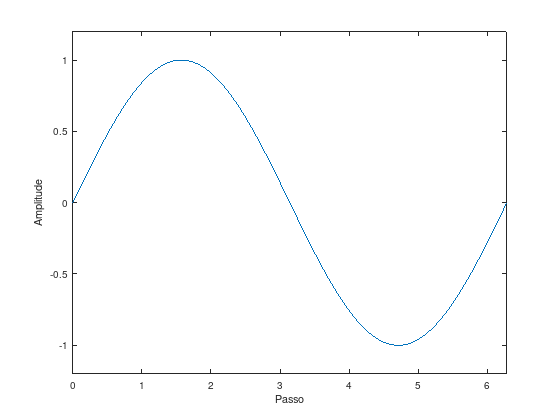

In [1]:
deg = 0:.001:2*pi;
flux = sin(deg);
plot(deg, flux);
xlabel('Passo'); ylabel('Amplitude');
axis([deg(1) deg(end) -1.2 1.2]);

## Derivada

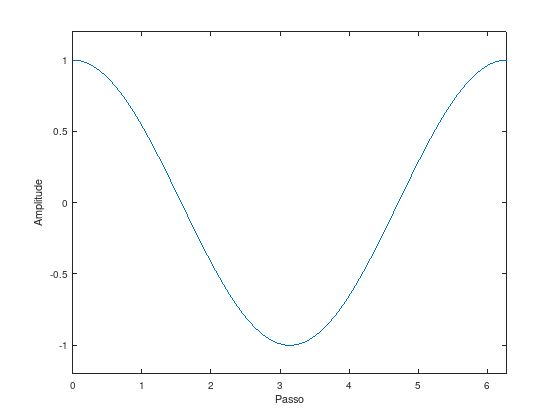

In [2]:
dflux = diff(flux)./diff(deg);
plot(deg(1:end-1), dflux);
xlabel('Passo'); ylabel('Amplitude');
axis([deg(1) deg(end) -1.2 1.2]);

## Integral


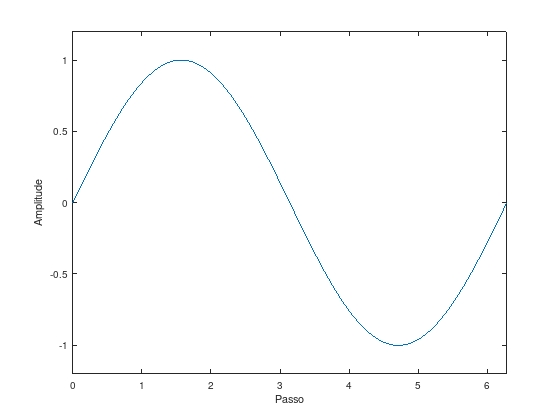

In [3]:
i_dflux = cumtrapz(deg(1:end-1),dflux);
plot(deg(1:end-1), i_dflux);
xlabel('Passo'); ylabel('Amplitude');
axis([deg(1) deg(end) -1.2 1.2]);

### Plot all

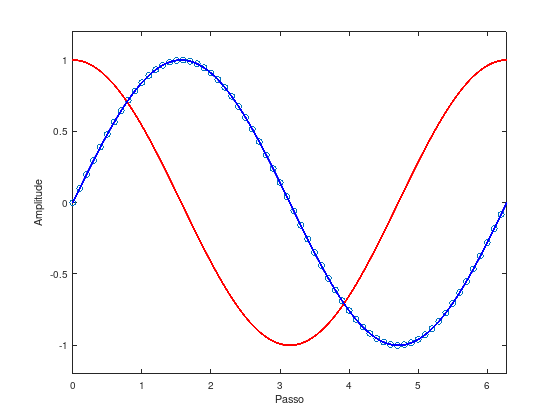

In [9]:
plot(deg(1:100:end-1), flux(1:100:end-1), '-o', ...
    deg(1:end-1), dflux, '-r', 'Linewidth', 2, ...
    deg(1:end-1), i_dflux, '-b', 'Linewidth', 2);
xlabel('Passo'); ylabel('Amplitude');
axis([deg(1) deg(end) -1.2 1.2]);

## No tempo

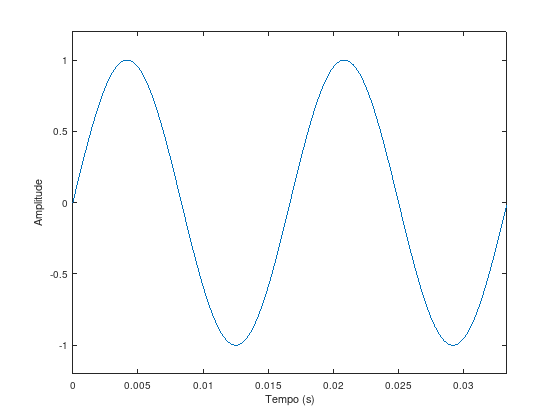

In [14]:
t = 0:.0001:2/60;
w = 2*pi*60;
flux_t = sin(w*t);
plot(t, flux_t);
xlabel('Tempo (s)'); ylabel('Amplitude');
axis([t(1) t(end) -1.2 1.2]);

### Derivada

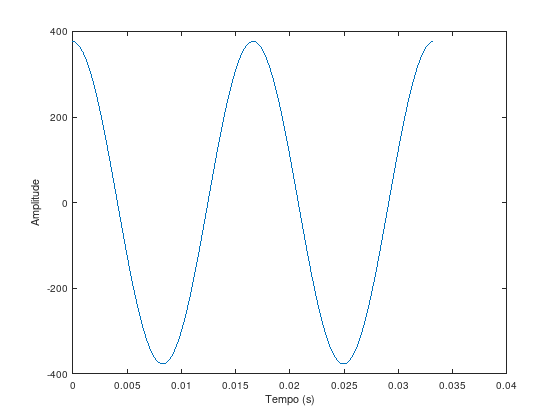

In [19]:
V = diff(flux_t)./diff(t);
plot(t(1:end-1), V)
xlabel('Tempo (s)'); ylabel('Amplitude');
% axis([t(1) t(end) -1.2 1.2]);

Aplicando a teoria de tensão induzida.

$$ V = \omega \lambda $$

In [23]:
% Valores de pico
V_rms = w * max(flux)
% Valor da derivada
max(V)

V_rms =  376.99
ans =  376.96


Realizando a integral da tensão.

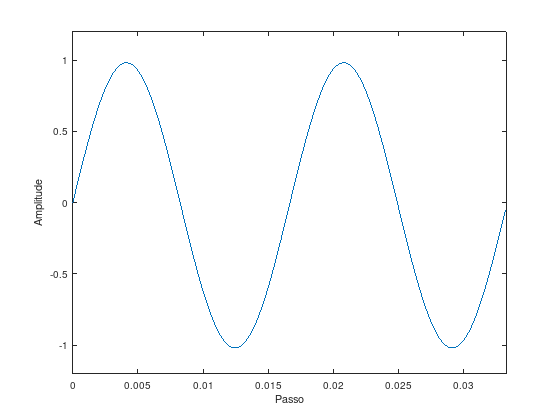

In [26]:
i_flux_t = cumtrapz(t(1:end-1),V);
plot(t(1:end-1), i_flux_t);
xlabel('Passo'); ylabel('Amplitude');
axis([t(1) t(end) -1.2 1.2]);

## Campo girante a partir das correntes

In [27]:
ia = sin(w*t);
ib = sin(w*t - 2*pi/3);
ic = sin(w*t + 2*pi/3);

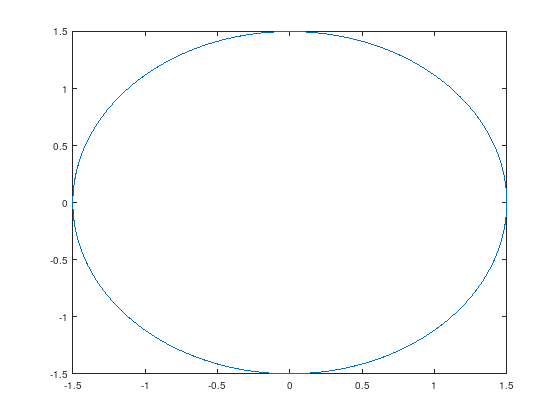

In [30]:
Fmm = ia*exp(j*0) + ib*exp(j*-2*pi/3) + ic*exp(j*2*pi/3);
plot(Fmm)
axis([-1.5 1.5 -1.5 1.5])

### Injetando harmônicos

In [35]:
ia = sin(w*t) + 1/10*sin(5*w*t);
ib = sin(w*t - 2*pi/3) + 1/10*sin(5*w*t - 5*2*pi/3);
ic = sin(w*t + 2*pi/3) + 1/10*sin(5*w*t + 5*2*pi/3);;

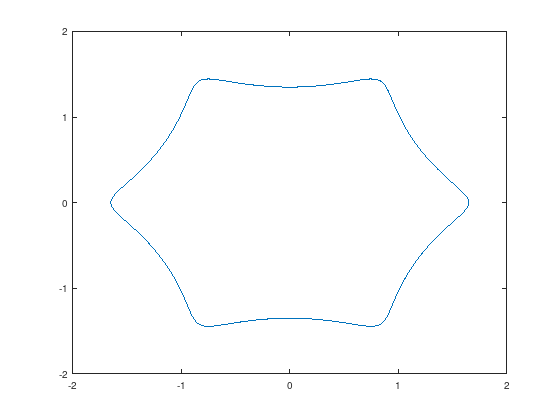

In [37]:
Fmm = ia*exp(j*0) + ib*exp(j*-2*pi/3) + ic*exp(j*2*pi/3);
plot(Fmm)
axis([-2 2 -2 2])